# 📉 Customer Churn Prediction — End-to-End ML Project

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)

**Pipeline:** Data Cleaning → Univariate/Bivariate/Multivariate EDA → Feature Engineering →
Encoding & Scaling → PCA (dimensionality reduction) → SMOTE (class imbalance) → XGBoost (modeling) →
Hyperparameter Tuning → Evaluation → Business Insights

---


## 1. Imports & Setup

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")
print("XGBoost version:", xgb.__version__)


Libraries loaded successfully.
XGBoost version: 3.4.1


## 2. Load the Dataset

Using the classic **Telco Customer Churn** dataset (IBM sample dataset, widely used on Kaggle).
It is a genuinely "messy" real-world dataset: `TotalCharges` is stored as text (with blank strings
for brand-new customers), `SeniorCitizen` is encoded as 0/1 while other flags are Yes/No, and several
service columns use a 3rd category (`"No internet service"` / `"No phone service"`) that overlaps
conceptually with `"No"`.


In [2]:

df = pd.read_csv('data/telco_churn.csv')
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:

df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

### 3.1 Messiness audit
- `TotalCharges` is `object` dtype instead of numeric — likely hides blank/whitespace strings.
- `customerID` is a pure identifier — not predictive, should be dropped before modeling.
- `SeniorCitizen` is 0/1 (int) while conceptually similar columns are Yes/No (str) — inconsistent encoding.
- Check for duplicate rows and missing values.


In [5]:

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Duplicate customer IDs
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

# Missing values (as pandas sees them)
print("\nMissing values per column:\n", df.isna().sum()[df.isna().sum() > 0])

# TotalCharges messiness: blank / whitespace strings hidden as strings
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(f"\n'TotalCharges' blank-string rows: {blank_mask.sum()}")
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Duplicate rows: 0
Duplicate customerIDs: 0

Missing values per column:
 Series([], dtype: int64)

'TotalCharges' blank-string rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [6]:

# Fix TotalCharges: coerce to numeric, blanks -> NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after coercion:", df['TotalCharges'].isna().sum())

# All the blank rows have tenure == 0 (brand new customers, haven't been billed yet)
print("\ntenure for missing TotalCharges rows:")
print(df.loc[df['TotalCharges'].isna(), 'tenure'].value_counts())

# Impute sensibly: a brand new customer's TotalCharges ~= MonthlyCharges (or 0)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Recheck
print("\nRemaining missing values:", df.isna().sum().sum())


Missing TotalCharges after coercion: 11

tenure for missing TotalCharges rows:
tenure
0    11
Name: count, dtype: int64

Remaining missing values: 0


In [7]:

# Standardize SeniorCitizen to Yes/No for consistent, human-readable EDA plots
# (we keep a numeric copy for modeling later)
df['SeniorCitizen_Flag'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Drop pure identifier
df.drop(columns=['customerID'], inplace=True)

# Target sanity check
df['Churn'].value_counts(normalize=True) * 100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:

# Bucket tenure into readable groups — useful for EDA and as an engineered feature
def tenure_bucket(t):
    if t <= 12:
        return '0-1 yr'
    elif t <= 24:
        return '1-2 yr'
    elif t <= 48:
        return '2-4 yr'
    elif t <= 60:
        return '4-5 yr'
    else:
        return '5+ yr'

df['TenureGroup'] = df['tenure'].apply(tenure_bucket)
df[['tenure', 'TenureGroup']].sample(5, random_state=1)


,tenure,TenureGroup
3381,41,2-4 yr
6180,66,5+ yr
4829,12,0-1 yr
3737,5,0-1 yr
4249,10,0-1 yr


## 4. Univariate Analysis

Looking at each variable in isolation: its distribution, spread, skew, and outliers.


### 4.1 Target Variable — Churn

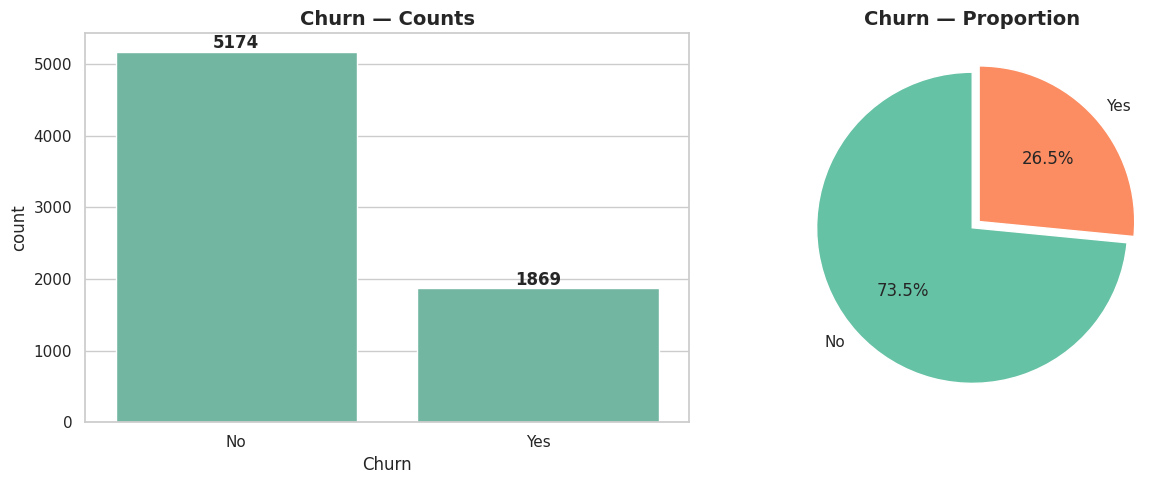

Churn rate: 26.54%  ->  clear class imbalance (~73/27), SMOTE is justified later.


In [9]:

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x='Churn', data=df, ax=axes[0], order=['No', 'Yes'])
axes[0].set_title('Churn — Counts')
for i, v in enumerate(churn_counts[['No', 'Yes']]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct[['No', 'Yes']], labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90, explode=(0, 0.06))
axes[1].set_title('Churn — Proportion')

plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.2f}%  ->  clear class imbalance (~73/27), SMOTE is justified later.")


### 4.2 Numerical Features — Distributions

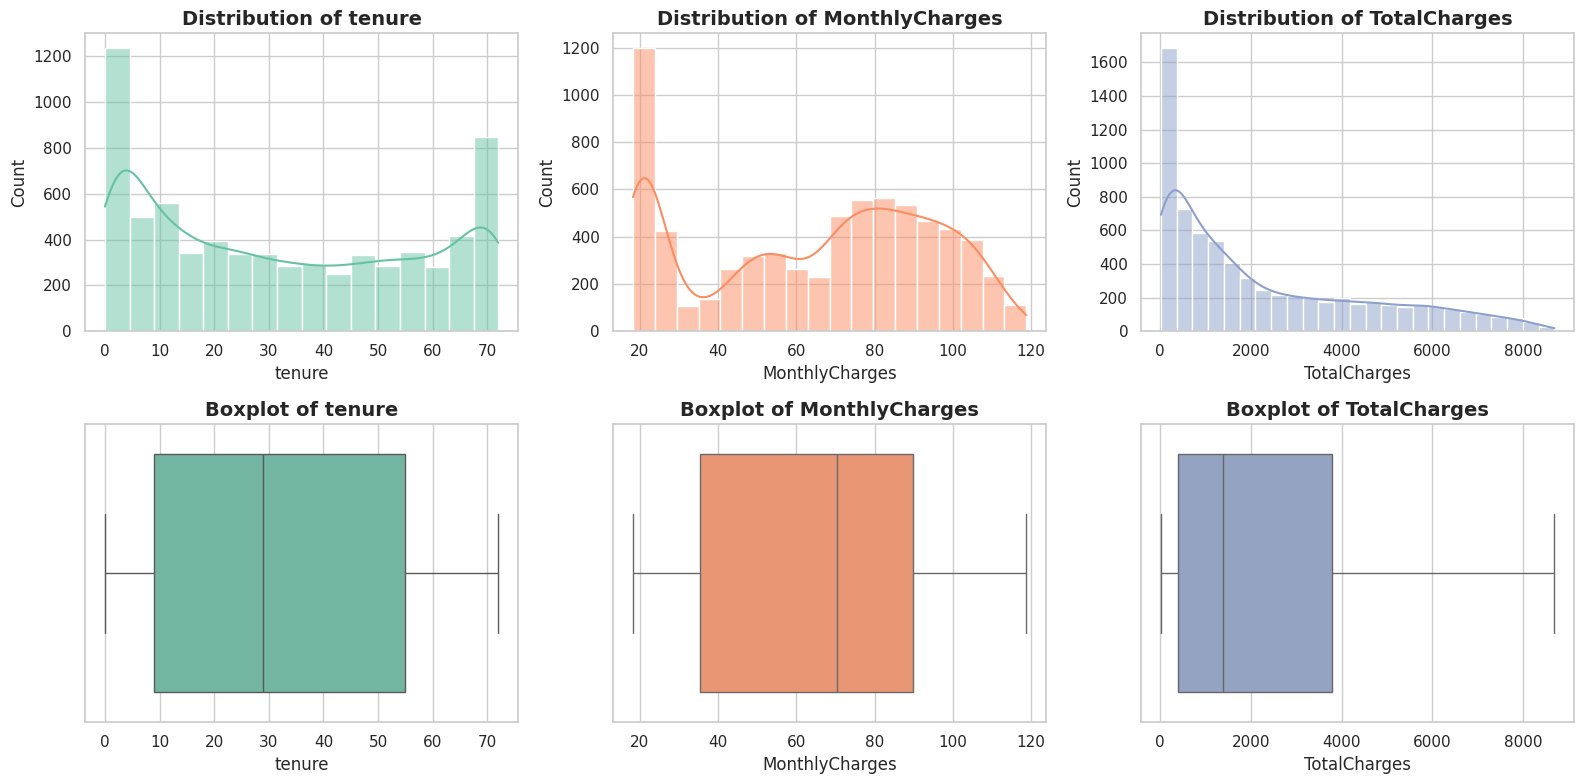

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963316
Name: skewness, dtype: float64

In [10]:

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=sns.color_palette('Set2')[i])
    axes[0, i].set_title(f'Distribution of {col}')

    sns.boxplot(x=df[col], ax=axes[1, i], color=sns.color_palette('Set2')[i])
    axes[1, i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

df[num_cols].skew().rename('skewness')


In [11]:

# Outlier scan via IQR
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:15s} -> IQR outliers: {n_out}  (range accepted: [{lower:.1f}, {upper:.1f}])")


tenure          -> IQR outliers: 0  (range accepted: [-60.0, 124.0])
MonthlyCharges  -> IQR outliers: 0  (range accepted: [-46.0, 171.4])
TotalCharges    -> IQR outliers: 0  (range accepted: [-4683.5, 8868.7])


### 4.3 Categorical Features — Distributions

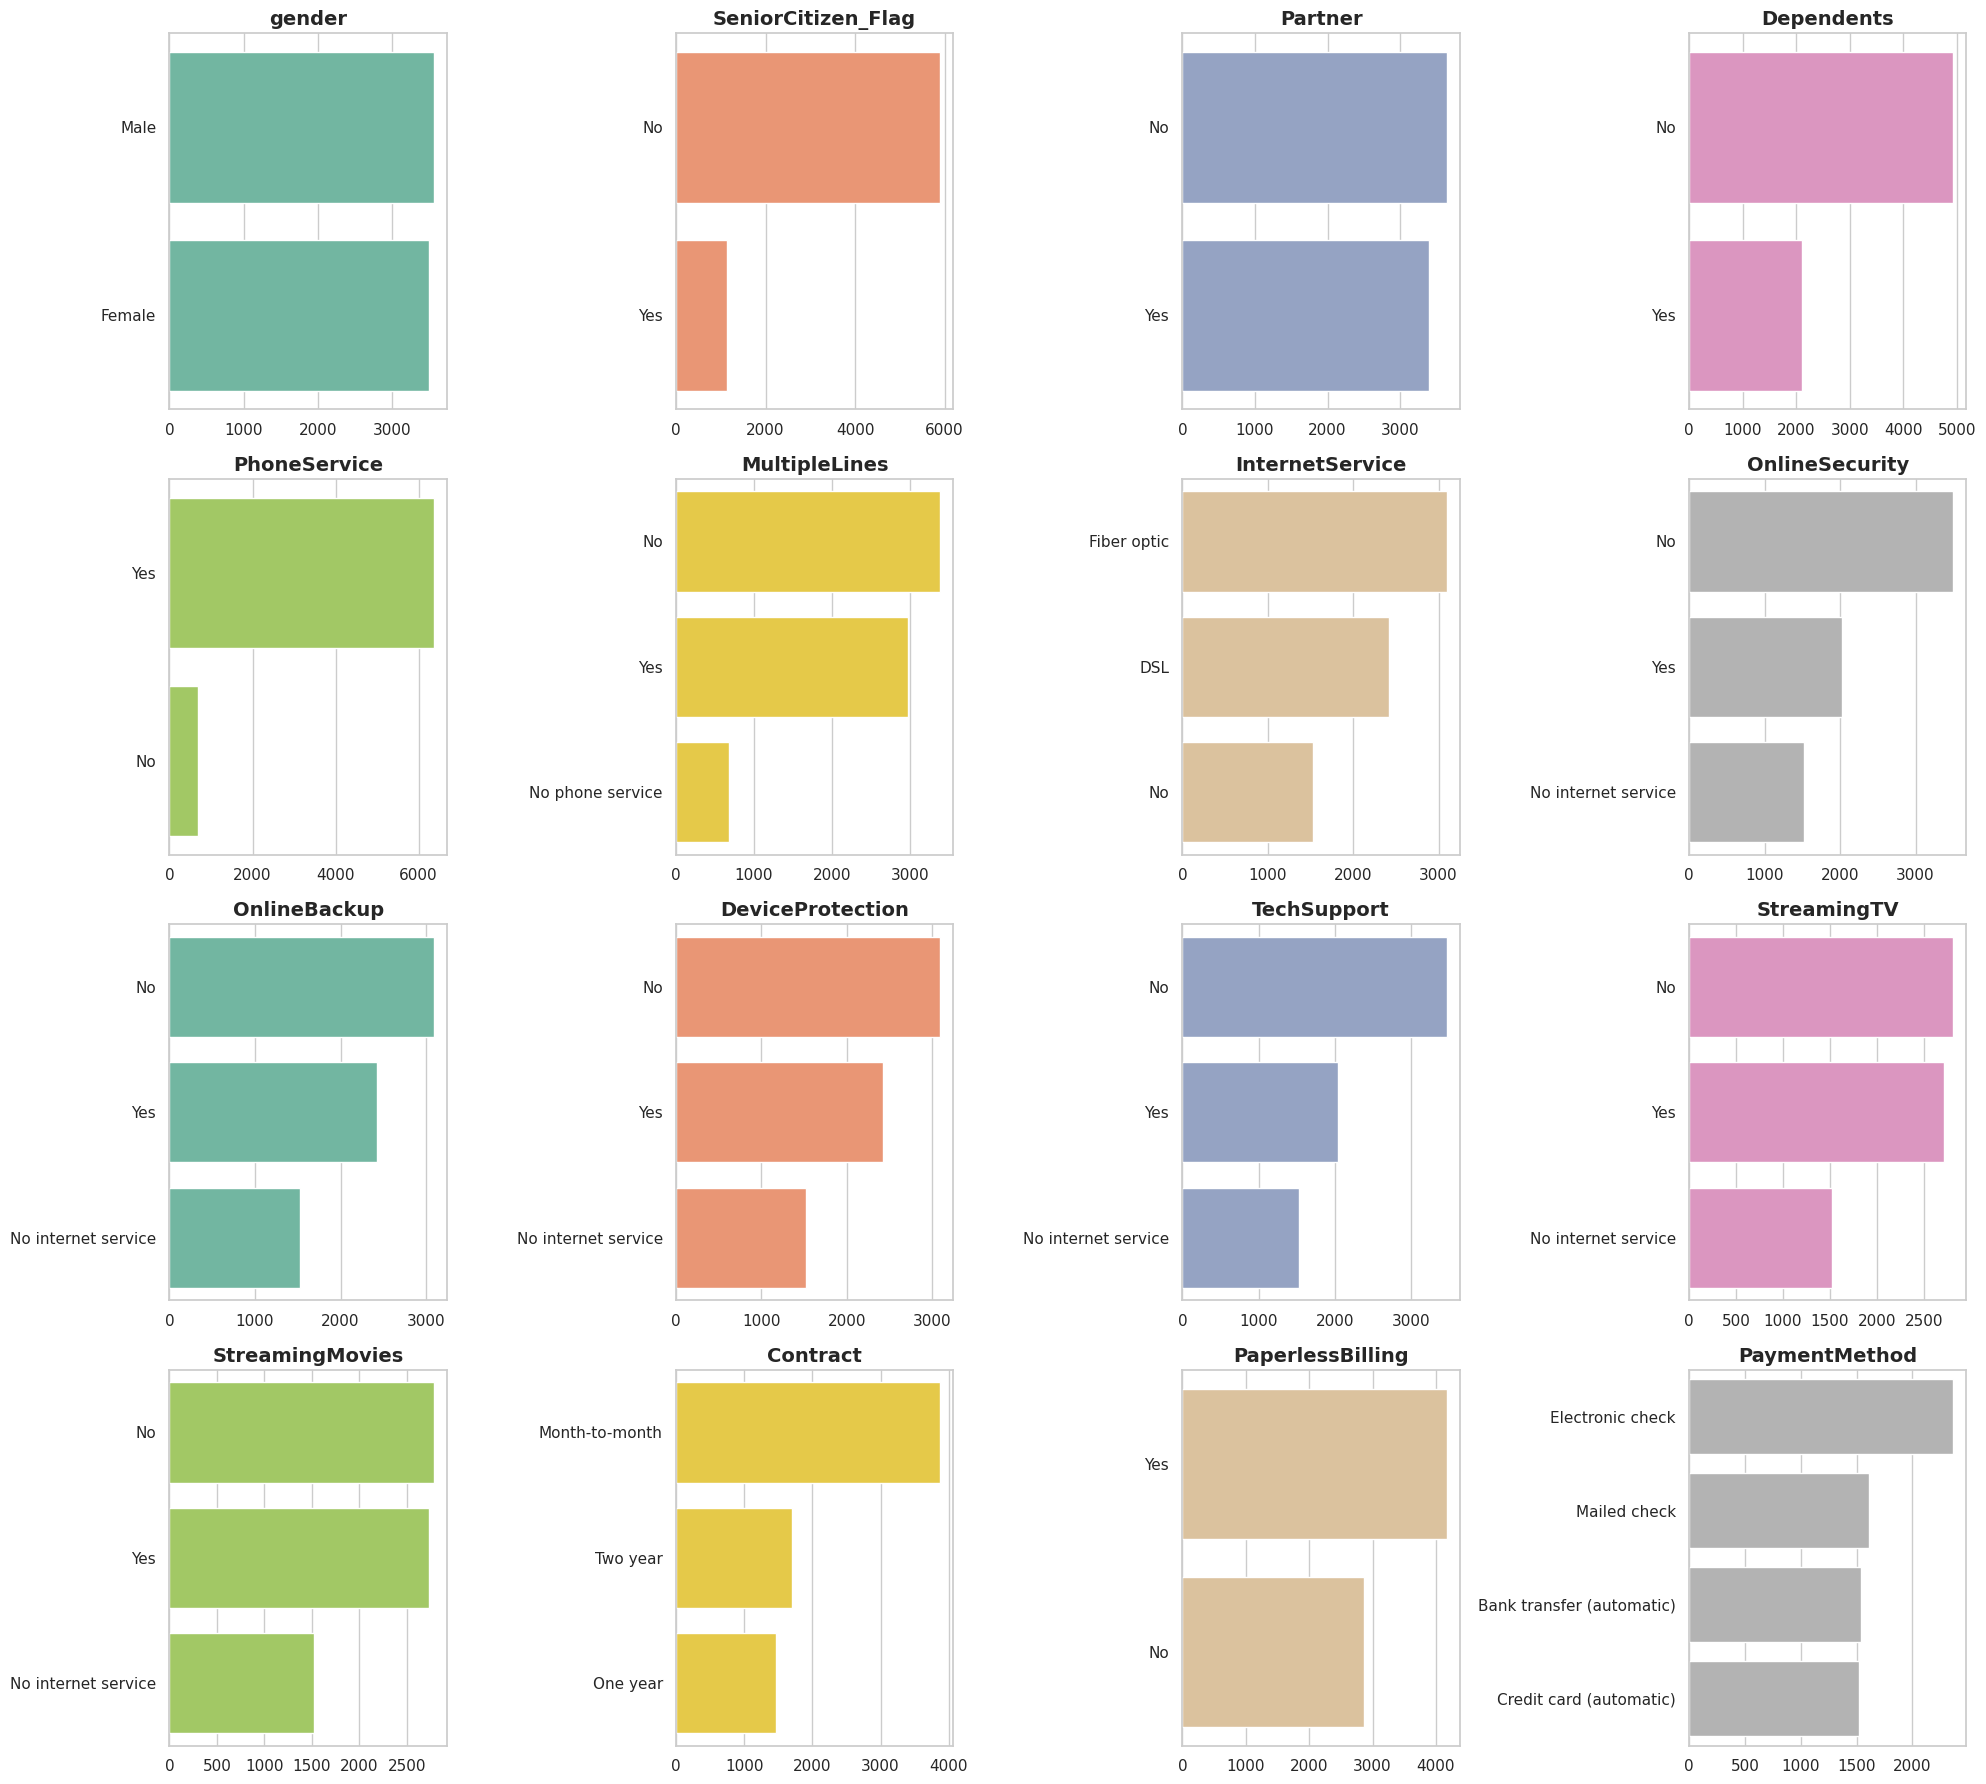

In [12]:

cat_cols = ['gender', 'SeniorCitizen_Flag', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], color=sns.color_palette('Set2')[i % 8])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


## 5. Bivariate Analysis

Relating each feature to the target (`Churn`) and to each other, to surface the strongest churn drivers.


### 5.1 Numerical features vs Churn

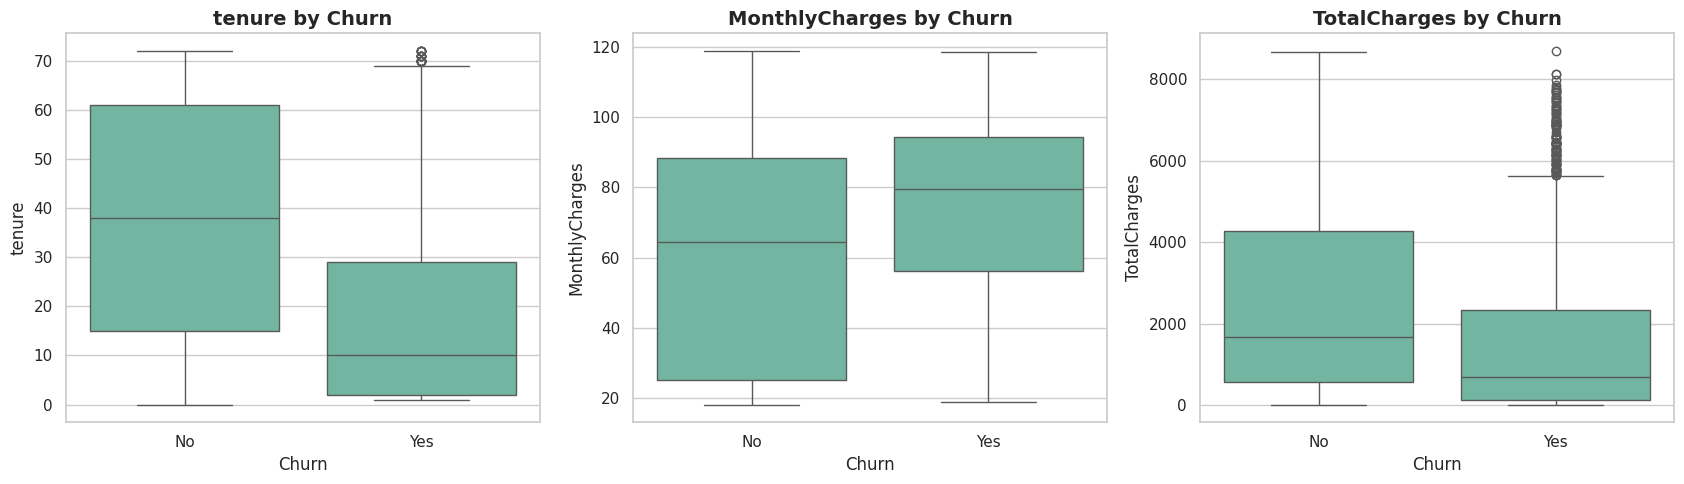

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], order=['No', 'Yes'])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()


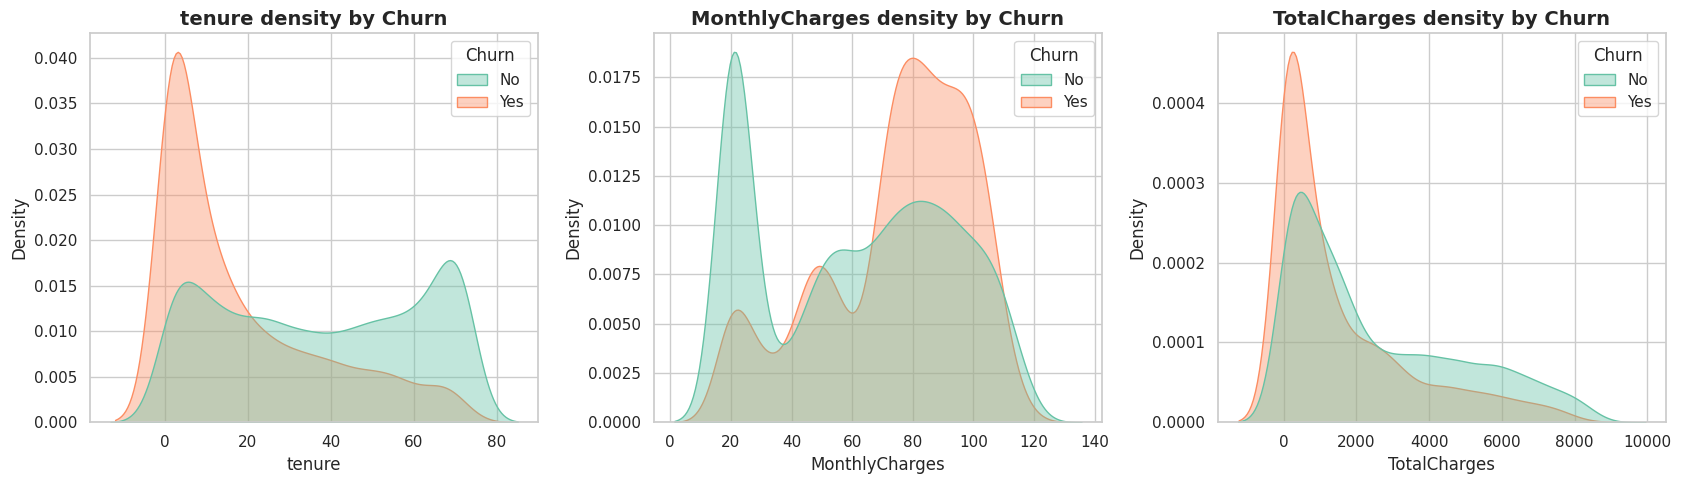

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2550.0
Yes      18.0            74.4        1531.8


In [14]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                alpha=0.4, ax=axes[i], hue_order=['No', 'Yes'])
    axes[i].set_title(f'{col} density by Churn')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')[num_cols].mean().round(1))


### 5.2 Categorical features vs Churn (% churn within each category)

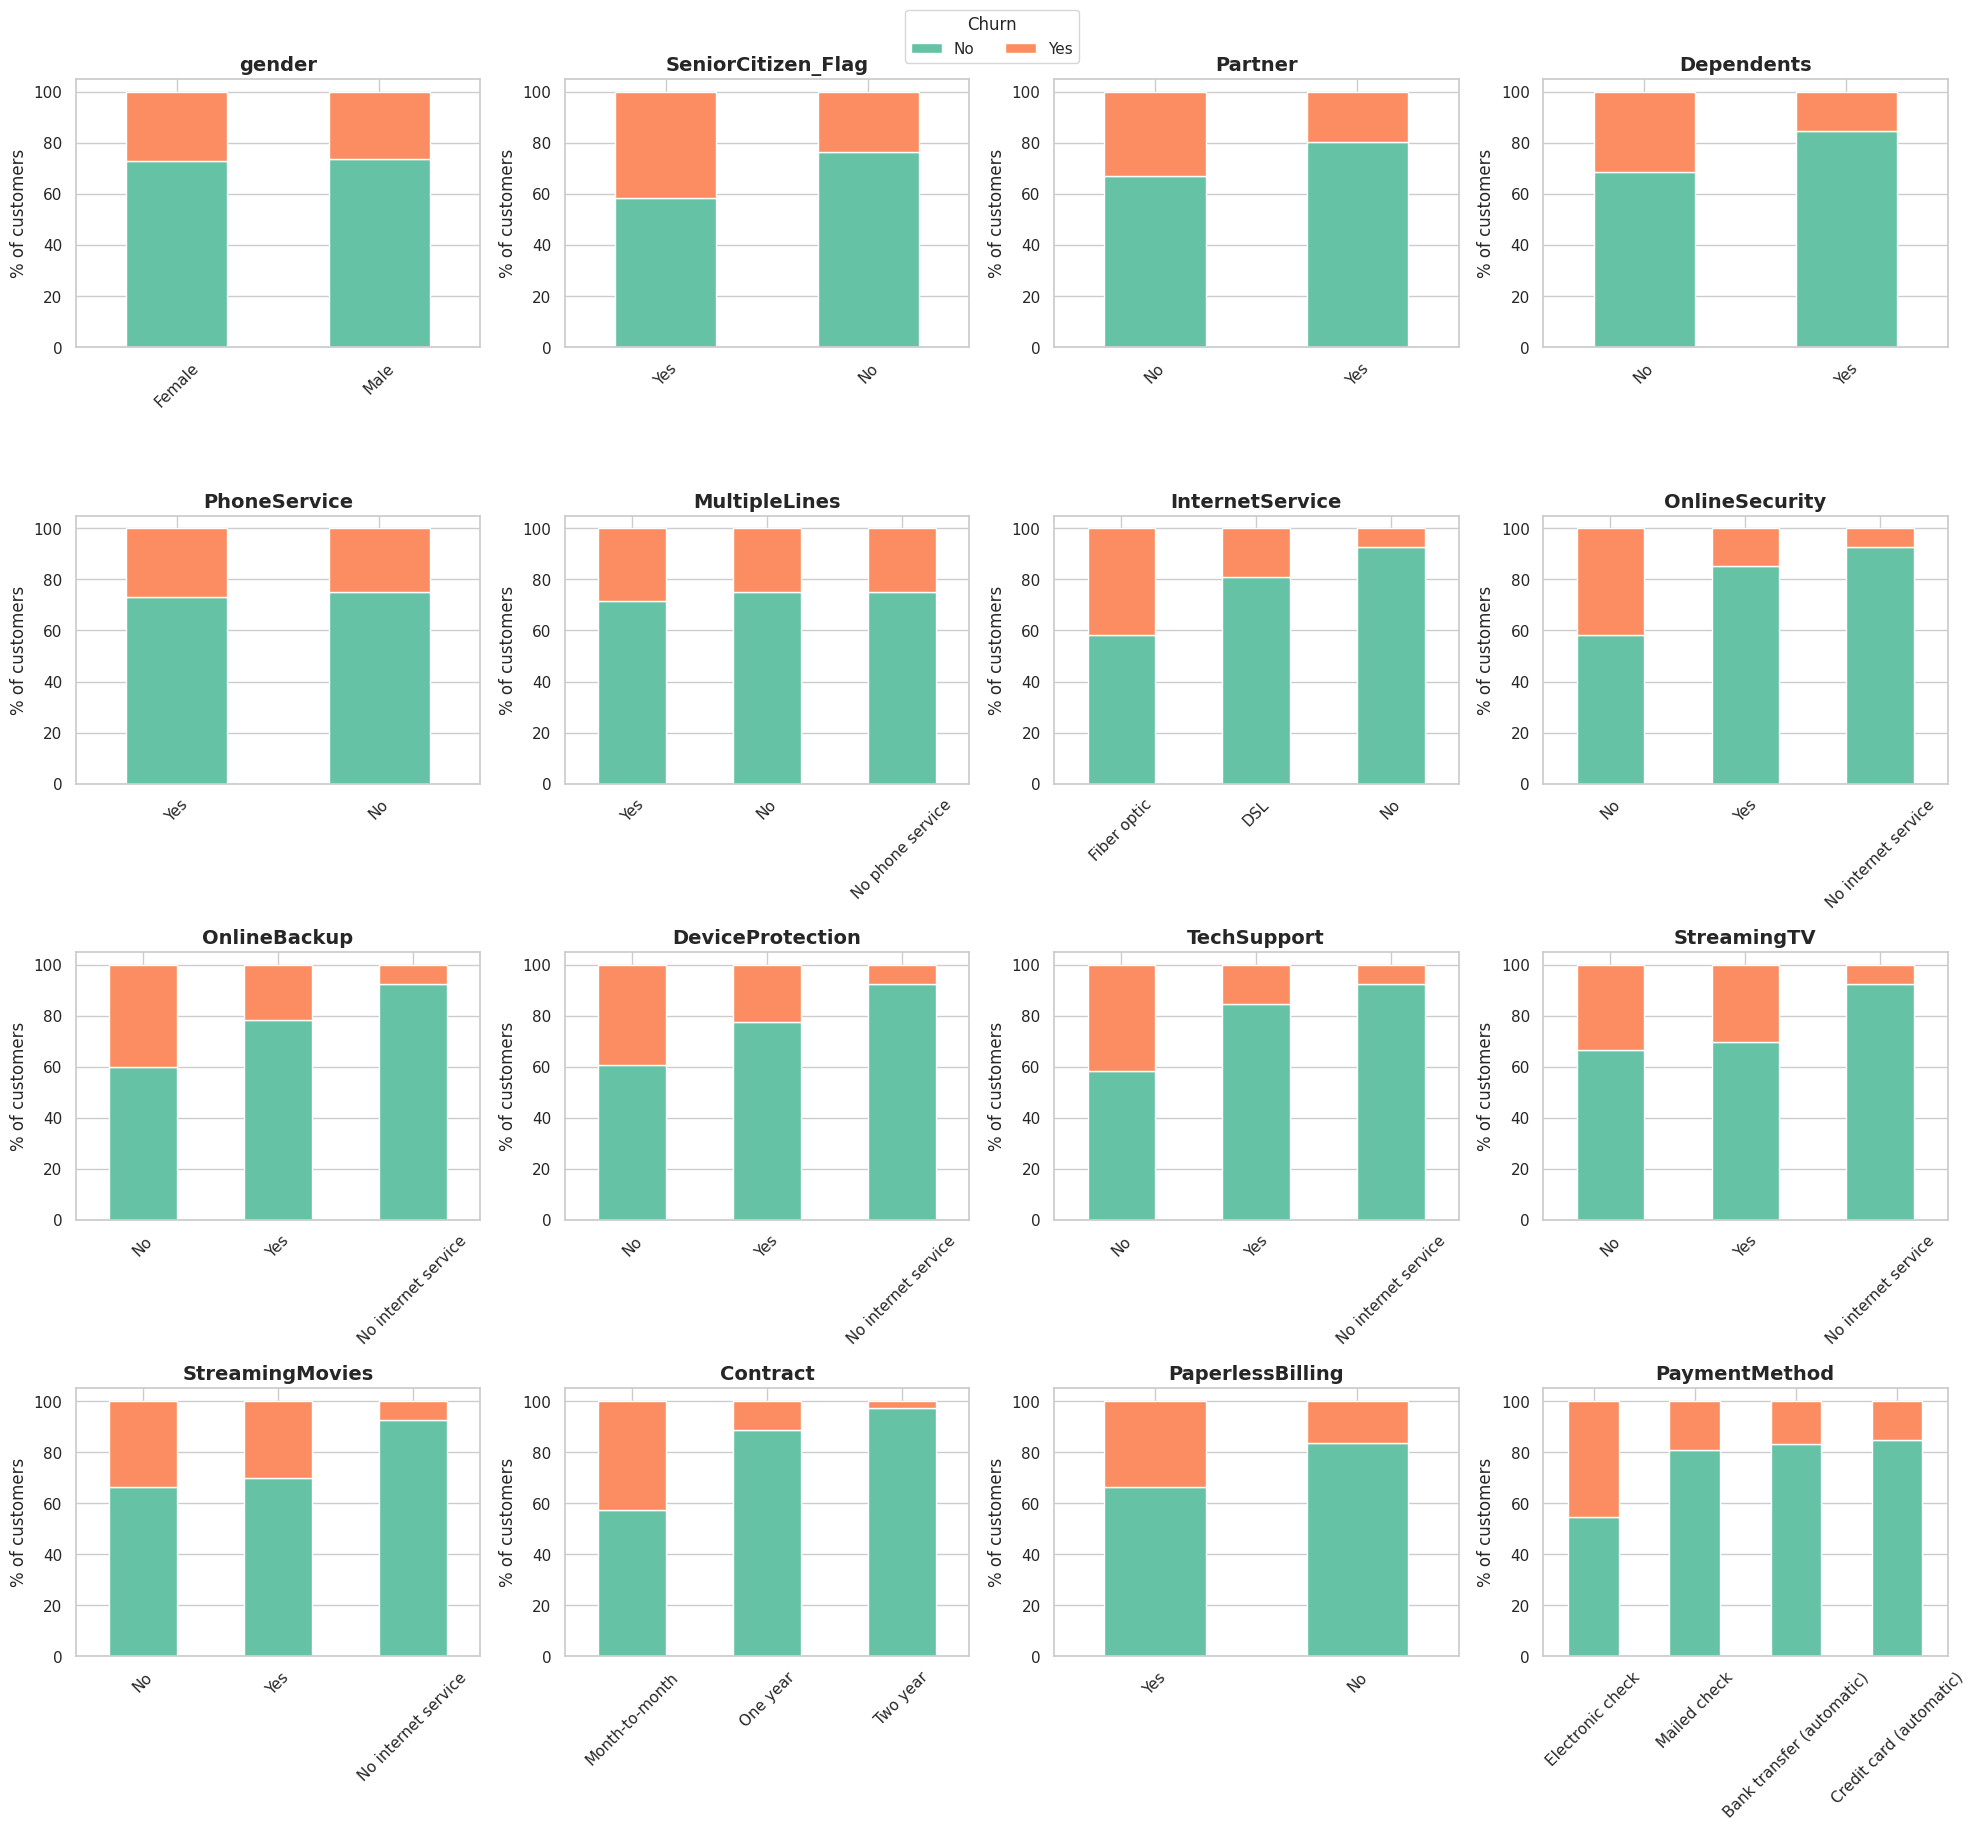

In [15]:

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct = ct.sort_values('Yes', ascending=False)
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=sns.color_palette('Set2')[:2], legend=False)
    axes[i].set_title(col)
    axes[i].set_ylabel('% of customers')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Churn', loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()


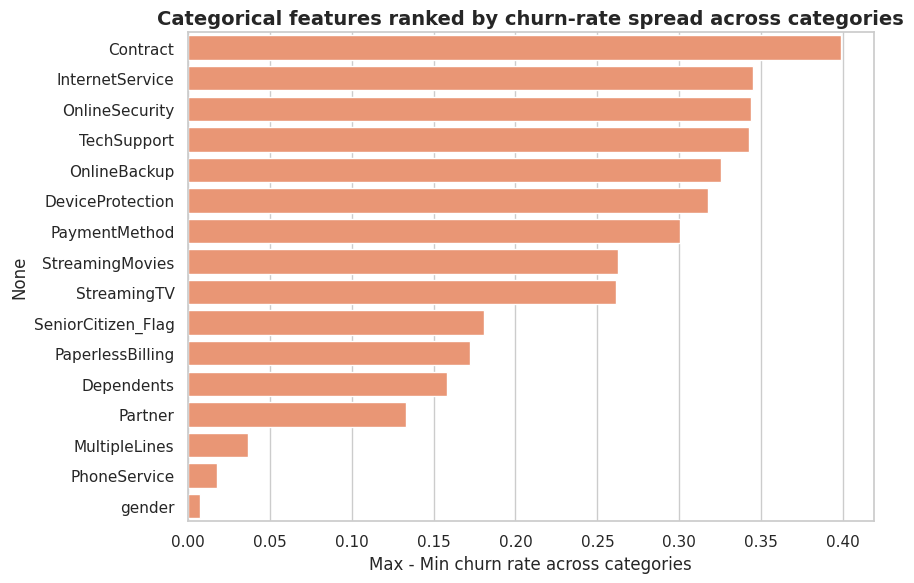

Contract              0.398778
InternetService       0.344878
OnlineSecurity        0.343617
TechSupport           0.342305
OnlineBackup          0.325238
DeviceProtection      0.317226
PaymentMethod         0.300423
StreamingMovies       0.262755
StreamingTV           0.261182
SeniorCitizen_Flag    0.180751
PaperlessBilling      0.172350
Dependents            0.158289
Partner               0.132931
MultipleLines         0.036832
PhoneService          0.017830
gender                0.007605
dtype: float64

In [16]:

# Rank categorical features by how strongly their categories separate churn rate
spread = {}
for col in cat_cols:
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean())
    spread[col] = rates.max() - rates.min()

spread_series = pd.Series(spread).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=spread_series.values, y=spread_series.index, color=sns.color_palette('Set2')[1])
plt.title('Categorical features ranked by churn-rate spread across categories')
plt.xlabel('Max - Min churn rate across categories')
plt.tight_layout()
plt.show()

spread_series


### 5.3 Correlation Heatmap (numeric features)

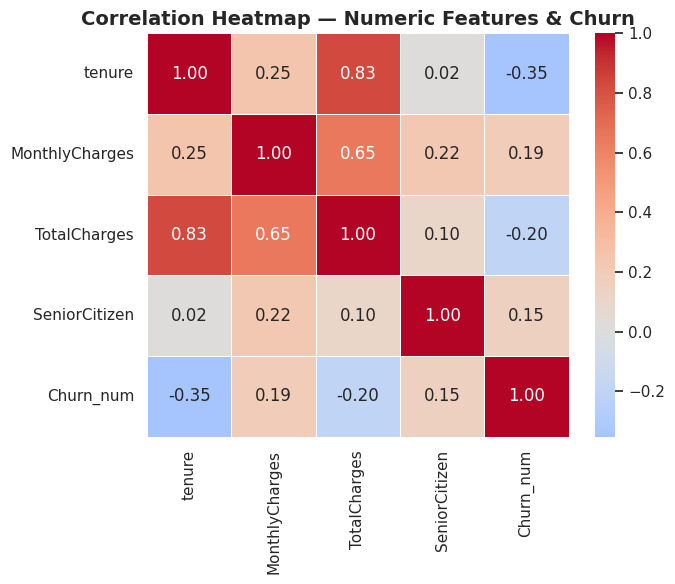

In [17]:

corr_df = df.copy()
corr_df['Churn_num'] = (corr_df['Churn'] == 'Yes').astype(int)
corr_matrix = corr_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features & Churn')
plt.tight_layout()
plt.show()


### 5.4 Pairplot (numeric features, colored by Churn)

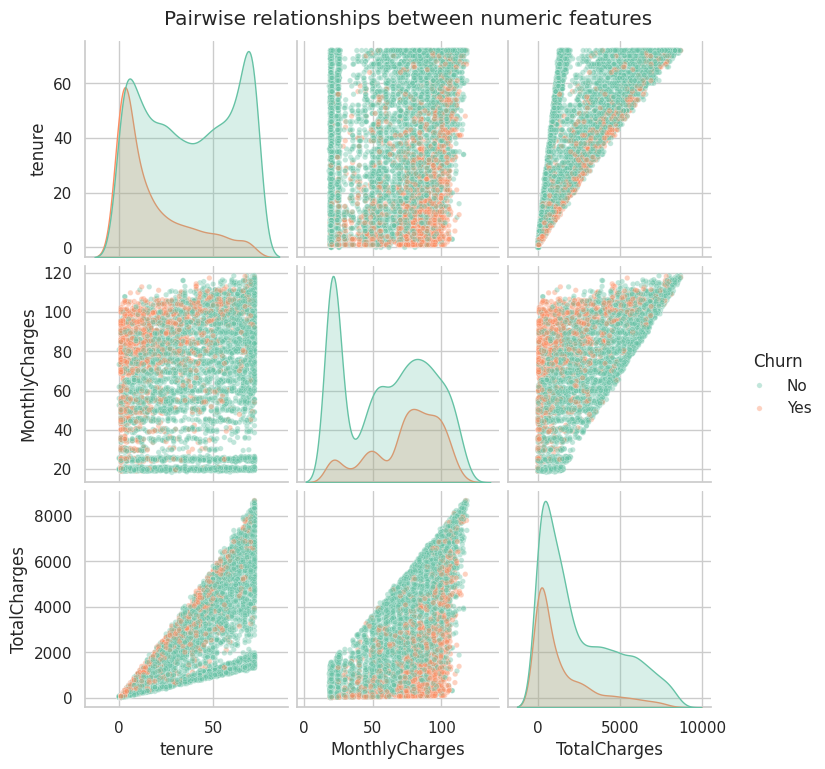

In [18]:

sns.pairplot(df, vars=num_cols, hue='Churn', hue_order=['No', 'Yes'],
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairwise relationships between numeric features', y=1.02)
plt.show()


## 6. Multivariate Analysis

Combining several variables at once to see interaction effects that simple bivariate views miss.


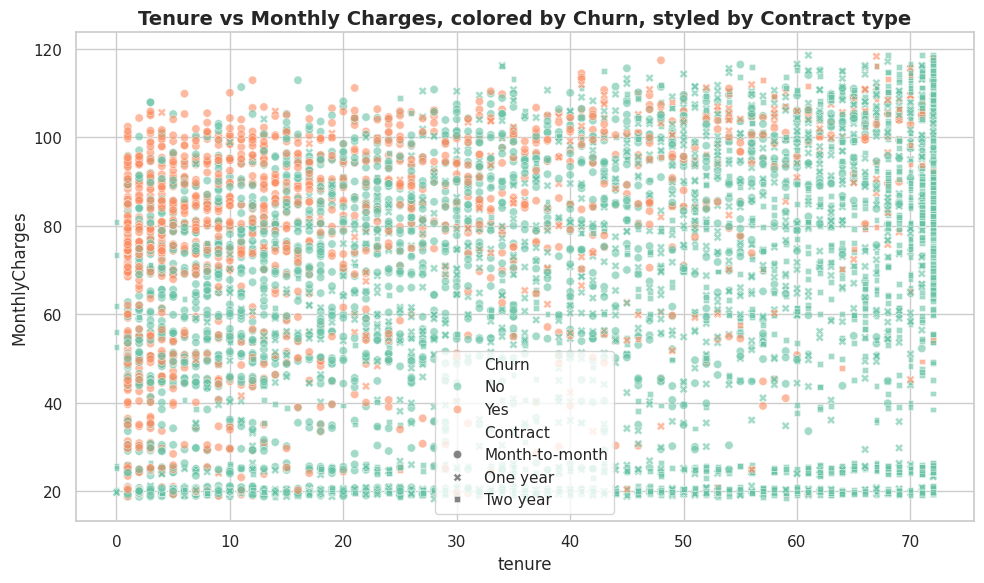

In [19]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', style='Contract',
                 alpha=0.6, hue_order=['No', 'Yes'])
plt.title('Tenure vs Monthly Charges, colored by Churn, styled by Contract type')
plt.tight_layout()
plt.show()


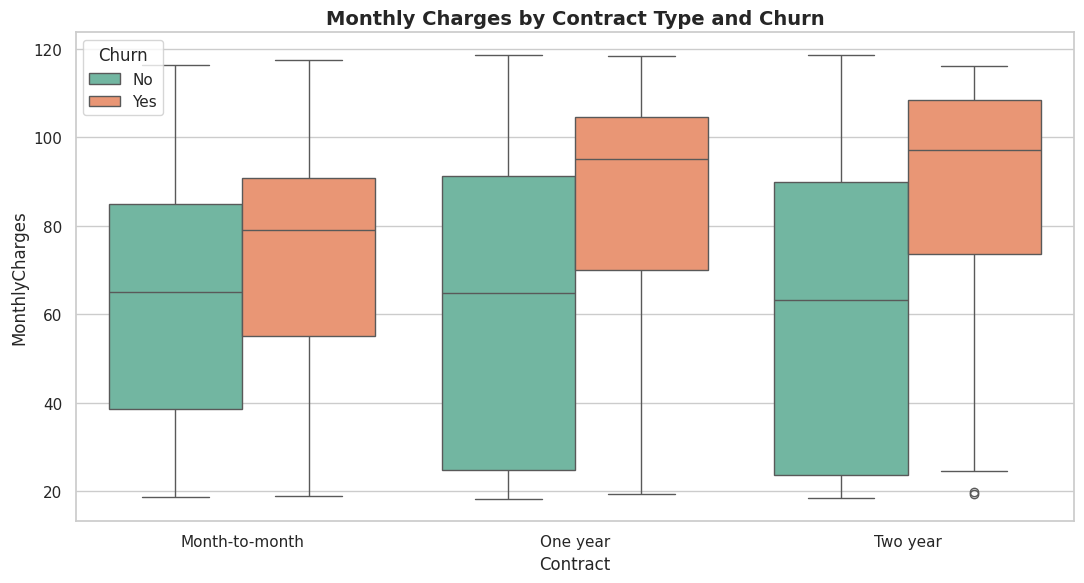

In [20]:

plt.figure(figsize=(11, 6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df, hue_order=['No', 'Yes'])
plt.title('Monthly Charges by Contract Type and Churn')
plt.tight_layout()
plt.show()


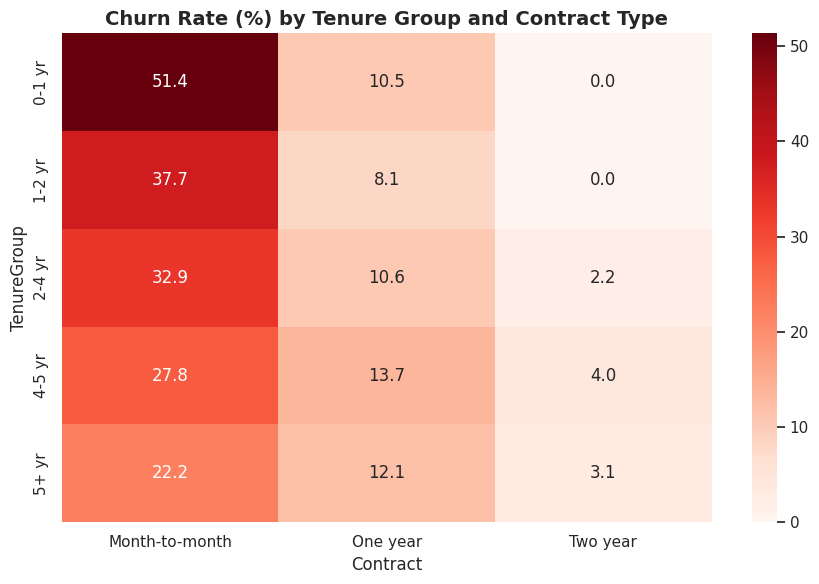

In [21]:

pivot = df.pivot_table(index='TenureGroup', columns='Contract', values='Churn',
                        aggfunc=lambda s: (s == 'Yes').mean() * 100)
pivot = pivot.reindex(['0-1 yr', '1-2 yr', '2-4 yr', '4-5 yr', '5+ yr'])

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) by Tenure Group and Contract Type')
plt.tight_layout()
plt.show()


### 6.1 EDA Takeaways (before modeling)

- **Churn is imbalanced** (~26.5% positive class) → SMOTE will be used before training.
- **Month-to-month contracts, fiber-optic internet, no tech support/online security, and
  electronic-check payment** are associated with visibly higher churn rates.
- **Short tenure and high monthly charges** correlate with churn; long tenure customers rarely churn.
- `tenure` and `TotalCharges` are strongly correlated (as expected, since total billed scales with time),
  which is useful context when interpreting PCA components and feature importance later.


## 7. Feature Engineering & Encoding

- Drop helper/display-only columns (`SeniorCitizen_Flag`, `TenureGroup` — created only for readable EDA plots).
- Add one engineered ratio feature (`AvgMonthlySpend`) that can carry signal beyond raw tenure/charges.
- One-hot encode categorical variables; label-encode the binary target.


In [22]:

model_df = df.drop(columns=['SeniorCitizen_Flag', 'TenureGroup']).copy()

# Engineered feature: average spend per month of tenure (guards divide-by-zero for tenure=0)
model_df['AvgMonthlySpend'] = model_df['TotalCharges'] / model_df['tenure'].replace(0, 1)

# Target encoding
le = LabelEncoder()
model_df['Churn'] = le.fit_transform(model_df['Churn'])  # No=0, Yes=1
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encode remaining categoricals
cat_features = model_df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns to encode:", cat_features)

model_df = pd.get_dummies(model_df, columns=cat_features, drop_first=True)
print("\nFinal shape after encoding:", model_df.shape)
model_df.head()


Classes: {'No': np.int64(0), 'Yes': np.int64(1)}

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final shape after encoding: (7043, 32)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,29.850000,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,55.573529,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,54.075000,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,40.905556,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,75.825000,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 8. Train/Test Split & Feature Scaling

In [23]:

X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: {:.2f}%  |  Test churn rate: {:.2f}%".format(
    y_train.mean() * 100, y_test.mean() * 100))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (5634, 31)  Test shape: (1409, 31)
Train churn rate: 26.54%  |  Test churn rate: 26.54%


## 9. Dimensionality Reduction — PCA

We apply PCA on the scaled features for two purposes:
1. **Visualization** — project to 2D to see how separable the classes are.
2. **Explained variance analysis** — decide how many components capture most of the signal
   (useful if the feature space were much larger; here it also demonstrates the technique end-to-end).


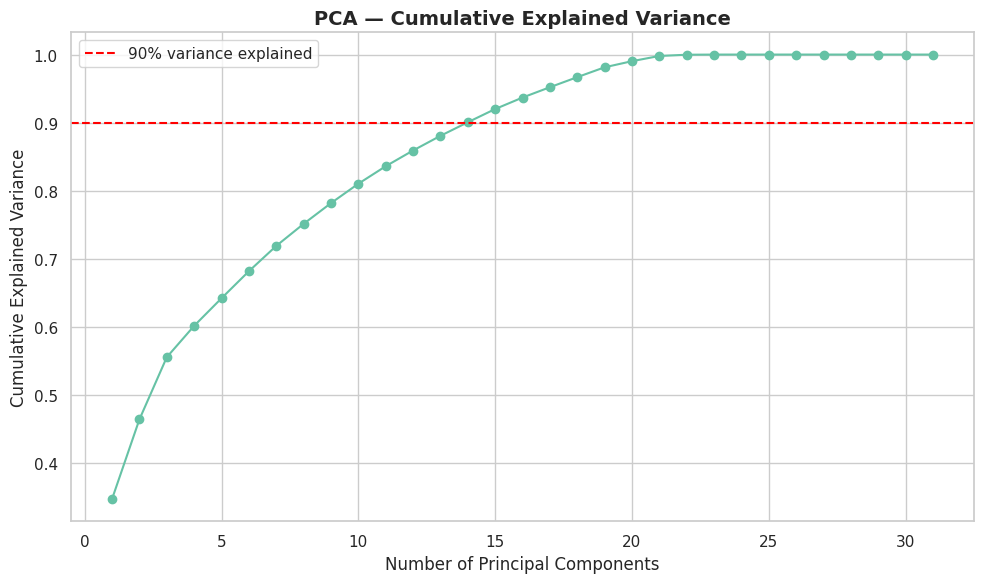

Components needed to explain >=90% variance: 14 (out of 31 original features)


In [24]:

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance explained')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components needed to explain >=90% variance: {n_components_90} (out of {X_train_scaled.shape[1]} original features)")


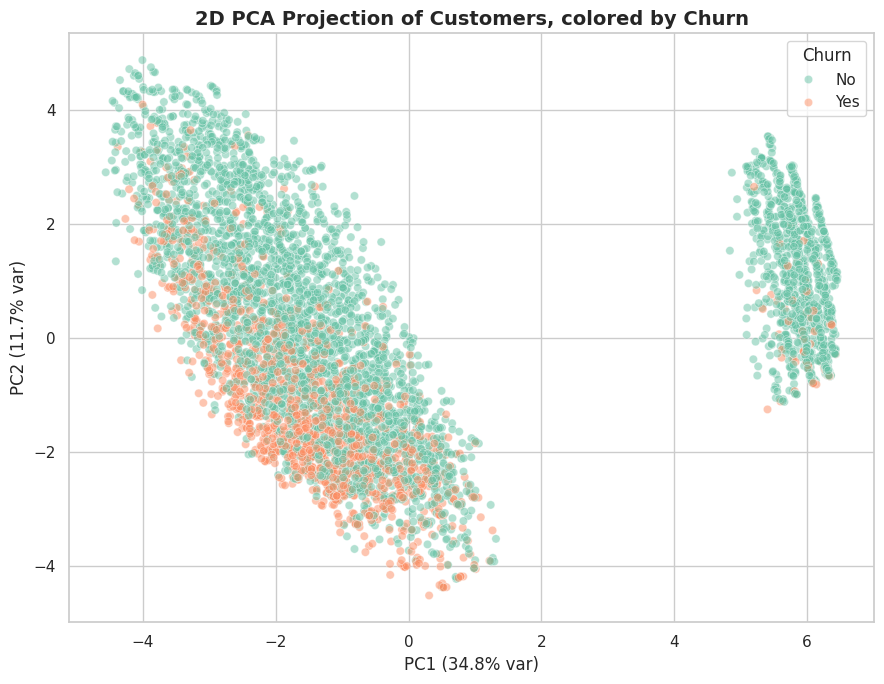

In [25]:

# 2D projection purely for visualizing class separability
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train.map({0: 'No', 1: 'Yes'}),
                 alpha=0.5, hue_order=['No', 'Yes'])
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('2D PCA Projection of Customers, colored by Churn')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


In [26]:

# Fit the PCA representation actually used for modeling (retain 90% variance)
pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced feature space: {X_train_pca.shape[1]} components "
      f"(from {X_train_scaled.shape[1]} original features), "
      f"explaining {pca.explained_variance_ratio_.sum()*100:.1f}% of variance.")


Reduced feature space: 14 components (from 31 original features), explaining 90.1% of variance.


## 10. Handling Class Imbalance — SMOTE

Churn is imbalanced (~73% No / ~27% Yes). We apply **SMOTE** (Synthetic Minority Over-sampling
Technique) **on the training set only**, after the PCA transform, to avoid leaking test-set
information and to avoid synthesizing points in an unscaled space.


Before SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
After SMOTE : {0: np.int64(4139), 1: np.int64(4139)}


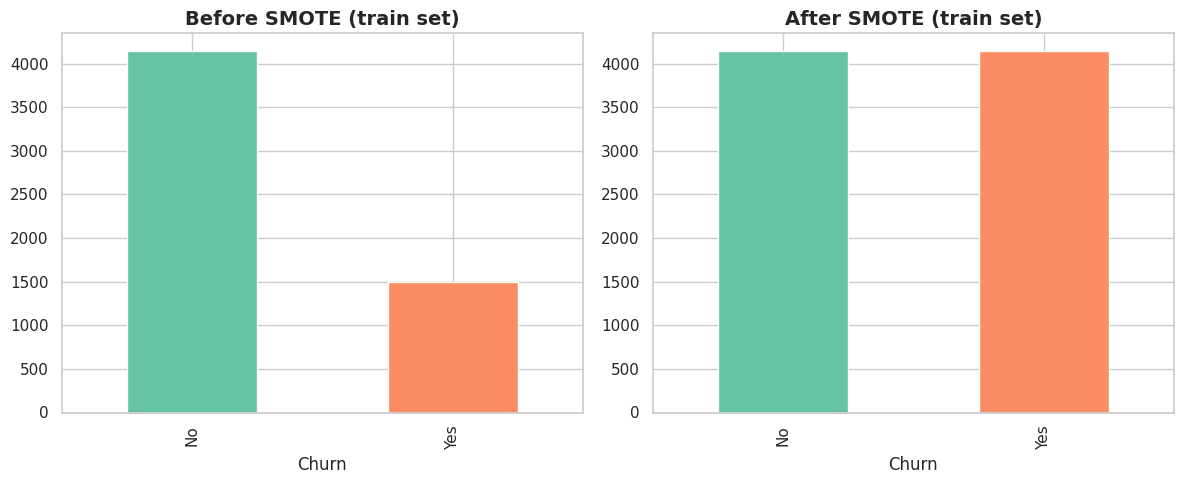

In [27]:

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_pca, y_train)

print("After SMOTE :", dict(pd.Series(y_train_res).value_counts()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(y_train).map({0: 'No', 1: 'Yes'}).value_counts().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Before SMOTE (train set)')
pd.Series(y_train_res).map({0: 'No', 1: 'Yes'}).value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('After SMOTE (train set)')
plt.tight_layout()
plt.show()


## 11. Modeling — XGBoost

### 11.1 Baseline model
A first XGBoost classifier trained on the SMOTE-balanced, PCA-reduced training data with default-ish
sensible parameters, to establish a baseline before tuning.


In [28]:

baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model.fit(X_train_res, y_train_res)
baseline_preds = baseline_model.predict(X_test_pca)
baseline_proba = baseline_model.predict_proba(X_test_pca)[:, 1]

print("Baseline XGBoost — Test performance")
print(classification_report(y_test, baseline_preds, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_proba), 4))


Baseline XGBoost — Test performance
              precision    recall  f1-score   support

    No Churn       0.87      0.75      0.81      1035
       Churn       0.50      0.70      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

ROC-AUC: 0.8092


### 11.2 Hyperparameter Tuning (RandomizedSearchCV)

In [29]:

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2],
}

xgb_clf = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)

print("\nBest ROC-AUC (CV):", round(random_search.best_score_, 4))
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best ROC-AUC (CV): 0.9023
Best params:
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0.1
  n_estimators: 500
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.1
  gamma: 0.2
  colsample_bytree: 0.8


In [30]:

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_pca)
y_proba = best_model.predict_proba(X_test_pca)[:, 1]

print("Tuned XGBoost — Test performance")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))


Tuned XGBoost — Test performance
              precision    recall  f1-score   support

    No Churn       0.84      0.79      0.81      1035
       Churn       0.49      0.57      0.53       374

    accuracy                           0.73      1409
   macro avg       0.66      0.68      0.67      1409
weighted avg       0.74      0.73      0.74      1409

ROC-AUC: 0.7901


## 12. Model Evaluation

In [31]:

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
}
metrics_df = pd.DataFrame(metrics, index=['Tuned XGBoost']).T
metrics_df


,Tuned XGBoost
Accuracy,0.729595
Precision,0.491991
Recall,0.574866
F1-score,0.530210
ROC-AUC,0.790094


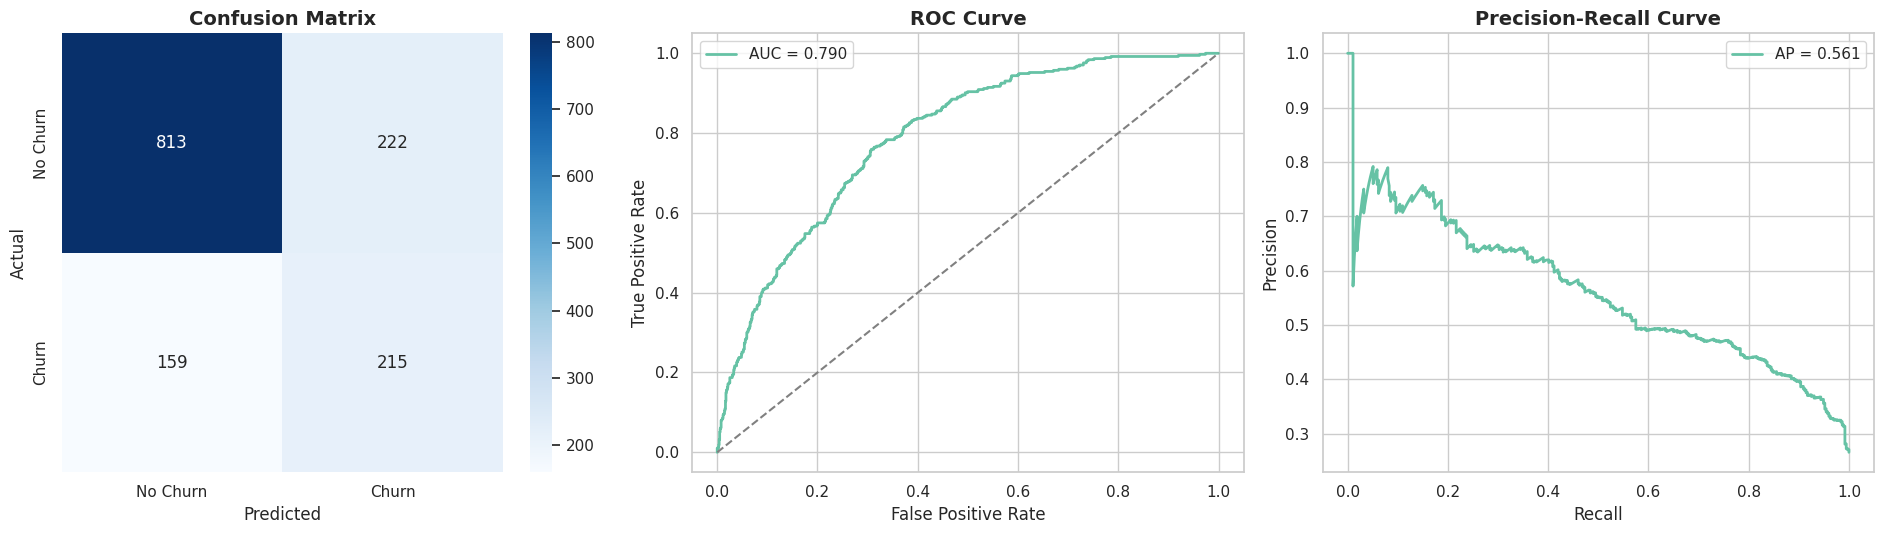

In [32]:

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)
axes[2].plot(recall, precision, label=f'AP = {ap_score:.3f}', linewidth=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.show()


### 12.1 Feature Importance

Since modeling happened in **PCA-transformed space**, raw XGBoost feature importances are per
principal component, not per original business feature. We show both: (a) importance of each PC,
and (b) which original features load most heavily onto the top PCs, so the result stays interpretable.


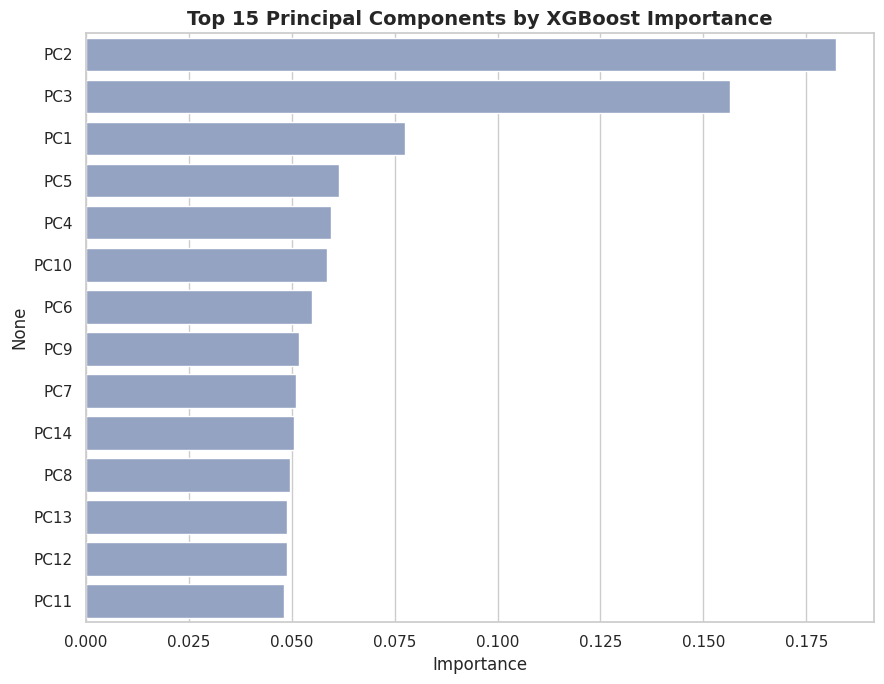

In [33]:

importances = best_model.feature_importances_
pc_names = [f'PC{i+1}' for i in range(len(importances))]

imp_series = pd.Series(importances, index=pc_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=imp_series.values, y=imp_series.index, color=sns.color_palette('Set2')[2])
plt.title('Top 15 Principal Components by XGBoost Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


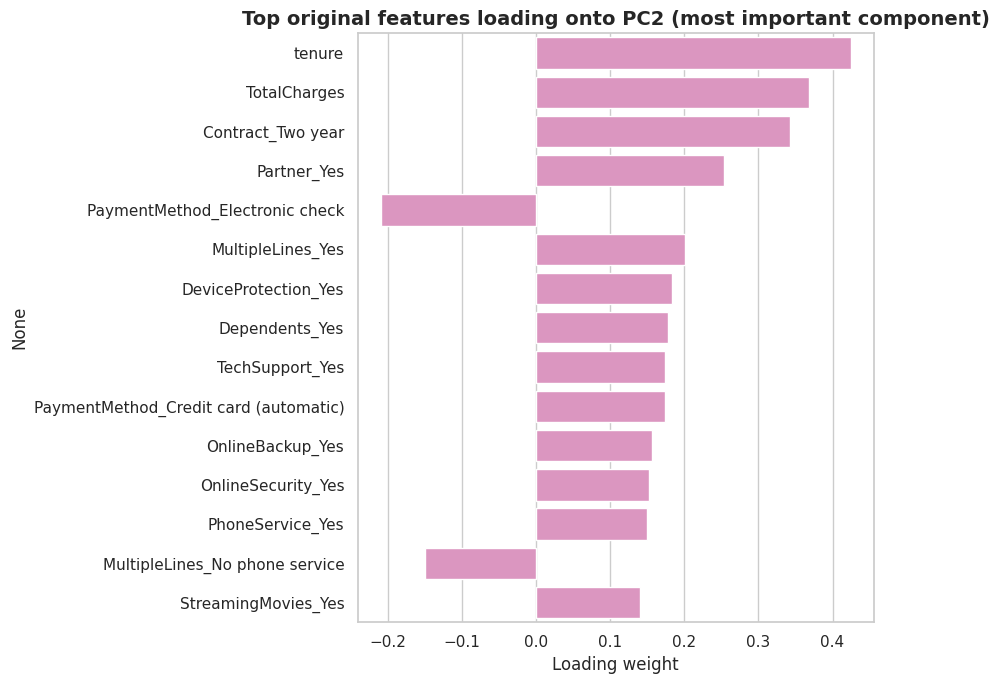

In [34]:

# Map the single most important PC back to original features via loadings
top_pc_idx = int(imp_series.index[0].replace('PC', '')) - 1
loadings = pd.Series(pca.components_[top_pc_idx], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=loadings.head(15).values, y=loadings.head(15).index, color=sns.color_palette('Set2')[3])
plt.title(f'Top original features loading onto {imp_series.index[0]} (most important component)')
plt.xlabel('Loading weight')
plt.tight_layout()
plt.show()


### 12.2 A model trained *without* PCA (for interpretability comparison)

PCA helps with multicollinearity/compactness but hides feature-level interpretability. As a
complementary view, we also fit XGBoost directly on the SMOTE-balanced **original (scaled) features**
so we can rank the true business drivers of churn.


No-PCA XGBoost — Test performance
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.84      1035
       Churn       0.57      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.8201


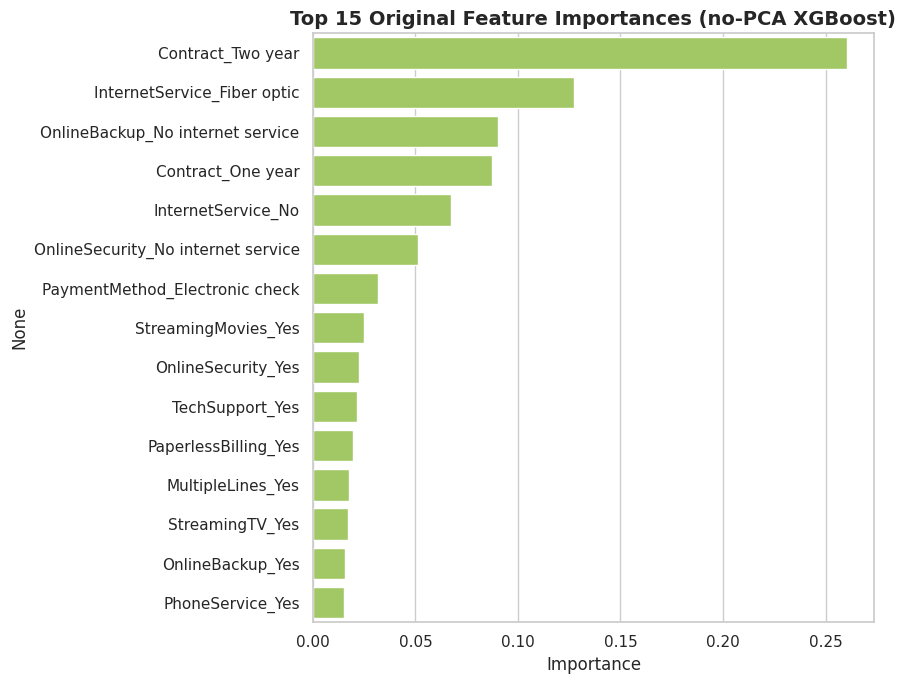

In [35]:

X_train_res_raw, y_train_res_raw = smote.fit_resample(X_train_scaled, y_train)

interp_model = XGBClassifier(
    n_estimators=best_model.get_params()['n_estimators'],
    max_depth=best_model.get_params()['max_depth'],
    learning_rate=best_model.get_params()['learning_rate'],
    subsample=best_model.get_params()['subsample'],
    colsample_bytree=best_model.get_params()['colsample_bytree'],
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
interp_model.fit(X_train_res_raw, y_train_res_raw)

interp_preds = interp_model.predict(X_test_scaled)
interp_proba = interp_model.predict_proba(X_test_scaled)[:, 1]
print("No-PCA XGBoost — Test performance")
print(classification_report(y_test, interp_preds, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", round(roc_auc_score(y_test, interp_proba), 4))

feat_imp = pd.Series(interp_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 7))
sns.barplot(x=feat_imp.values, y=feat_imp.index, color=sns.color_palette('Set2')[4])
plt.title('Top 15 Original Feature Importances (no-PCA XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 12.3 Model comparison summary

In [36]:

comparison = pd.DataFrame({
    'Baseline XGB (PCA+SMOTE)': [
        accuracy_score(y_test, baseline_preds), precision_score(y_test, baseline_preds),
        recall_score(y_test, baseline_preds), f1_score(y_test, baseline_preds),
        roc_auc_score(y_test, baseline_proba)
    ],
    'Tuned XGB (PCA+SMOTE)': [
        accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
        recall_score(y_test, y_pred), f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ],
    'Tuned-params XGB (No PCA, SMOTE)': [
        accuracy_score(y_test, interp_preds), precision_score(y_test, interp_preds),
        recall_score(y_test, interp_preds), f1_score(y_test, interp_preds),
        roc_auc_score(y_test, interp_proba)
    ],
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])

comparison.round(4)


,Baseline XGB (PCA+SMOTE),Tuned XGB (PCA+SMOTE),"Tuned-params XGB (No PCA, SMOTE)"
Accuracy,0.7367,0.7296,0.7693
Precision,0.5029,0.4920,0.5668
Recall,0.7005,0.5749,0.5561
F1-score,0.5855,0.5302,0.5614
ROC-AUC,0.8092,0.7901,0.8201


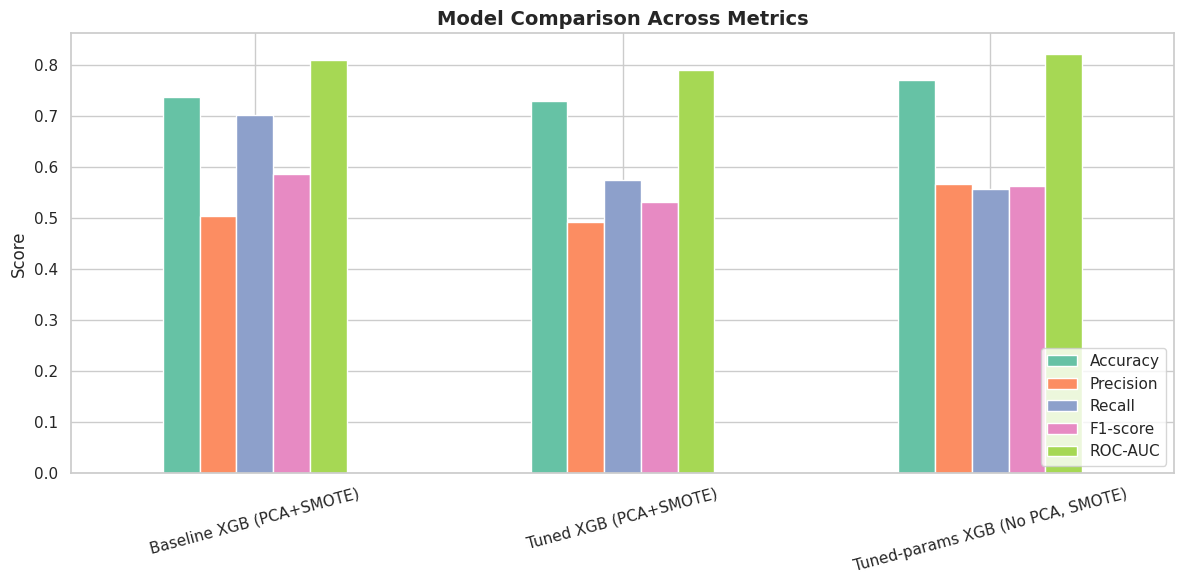

In [37]:

comparison.T.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 13. Conclusions & Business Recommendations

**Key churn drivers identified through EDA & feature importance:**
- **Contract type** — month-to-month customers churn far more than one/two-year contract holders.
- **Tenure** — churn risk is highest in the first 12 months; loyalty grows sharply afterward.
- **Internet service / add-ons** — fiber-optic customers without OnlineSecurity or TechSupport churn more.
- **Payment method** — electronic-check payers show a higher churn rate than automatic payment methods.
- **Monthly charges** — higher bills correlate with higher churn, especially for short-tenure customers.

**Modeling takeaways:**
- The dataset is imbalanced (~27% churn); **SMOTE** on the training set materially improves recall on
  the minority (churn) class versus training on the raw imbalanced data.
- **PCA** compresses the encoded feature space while retaining ~90% of variance, trading a little
  interpretability for a more compact representation — the no-PCA model is kept alongside for
  business-facing feature interpretation.
- **XGBoost** with tuned hyperparameters (via `RandomizedSearchCV` + stratified 5-fold CV, optimizing
  ROC-AUC) gives a strong balance of precision and recall for identifying at-risk customers.

**Suggested business actions:**
1. Target month-to-month, short-tenure customers with retention offers (e.g., discounted upgrade to
   a 1-year contract).
2. Bundle OnlineSecurity/TechSupport for fiber customers, since their absence correlates with churn.
3. Encourage a switch away from electronic check to automatic payment methods.
4. Use the model's churn probability score to prioritize proactive outreach from customer success teams.
